In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

# --- STEP 1: LOAD THE DATASET FROM YOUR GITHUB ---
# Converting the standard GitHub UI link to a raw data link automatically
github_url = "https://github.com/abuzar0905/Machine-Learning-Project/blob/main/Telco-Customer-Churn.csv"
raw_url = github_url.replace("github.com", "raw.githubusercontent.com").replace("/blob/", "/")

print("Fetching dataset from your GitHub repository...")
df = pd.read_csv(raw_url)

Fetching dataset from your GitHub repository...


# --- STEP 2: DATA PREPROCESSING & CLEANING ---

In [ ]:
# 1. TotalCharges has blank spaces ' ' which cause errors. Convert to numeric and fill NaN with median.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# 2. Drop unique ID column as it holds no predictive power
df = df.drop(columns=['customerID'])

# 3. Encode Target Variable 'Churn' (Yes = 1, No = 0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 4. Separate Features (X) and Target (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

# 5. One-Hot Encode remaining categorical columns (e.g., Contract, InternetService)
X = pd.get_dummies(X, drop_first=True)

# --- STEP 3: TRAIN-TEST SPLIT (80/20 Ratio) ---

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Identify the raw numerical columns that need scaling
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Initialize StandardScaler
scaler = StandardScaler()

# Create copies to prevent altering original datasets
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit the scaler on the training features and transform both sets
# (Crucial: ONLY scale continuous numerical columns, leave binary columns alone)
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# --- STEP 4: MODEL IMPLEMENTATION (Logistic Regression) ---

In [ ]:
print("Training the Scaled Logistic Regression model...")
improved_model = LogisticRegression(max_iter=1000, random_state=42)
improved_model.fit(X_train_scaled, y_train)

# Make improved predictions
y_pred = improved_model.predict(X_test_scaled)
y_prob = improved_model.predict_proba(X_test_scaled)[:, 1]

Training the Scaled Logistic Regression model...


# --- STEP 5: EVALUATION & METRICS ---

In [ ]:
print("\n" + "="*40)
print("     IMPROVED MODEL PERFORMANCE EVALUATION     ")
print("="*40)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))


     IMPROVED MODEL PERFORMANCE EVALUATION     
Accuracy Score: 0.8055
ROC-AUC Score: 0.8421

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



# --- STEP 6: VISUALIZATIONS ---

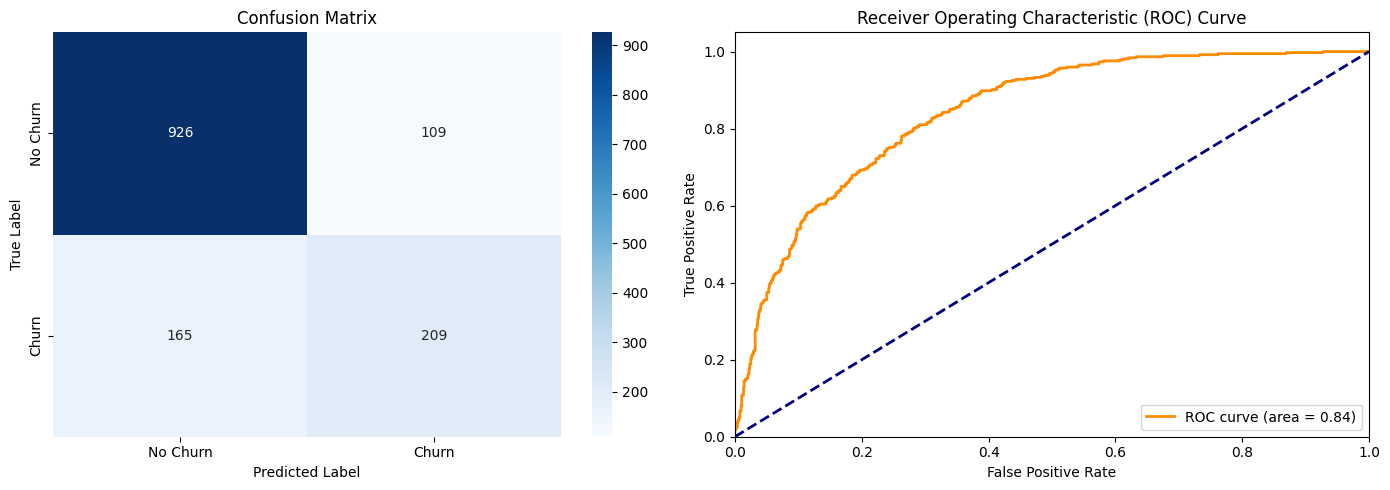

In [ ]:
# Plot Confusion Matrix and ROC Curve side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# 2. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_score(y_test, y_prob):.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()